# Model 1 — Forecast Bias-Correction: Out-of-Sample Results

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '/Users/maxzhalilo/Personal/kalshi/kalshi-carry/kalshi-weather/neural-net')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import evaluation
import config as cfg

df = pd.read_csv('checkpoints/model1_preds_test.csv', parse_dates=['date'])
print(f'Loaded {len(df)} rows, date range: {df.date.min()} to {df.date.max()}')
df.head()

Loaded 2120 rows, date range: 2026-01-01 00:00:00 to 2026-04-16 00:00:00


,date,ticker,mu,sigma,y_true
0,2026-01-01,KXHIGHAUS,71.261464,1.469932,72.9
1,2026-01-02,KXHIGHAUS,85.371253,1.435497,86.6
2,2026-01-03,KXHIGHAUS,73.571775,1.386589,74.4
3,2026-01-04,KXHIGHAUS,66.896387,1.340995,68.1
4,2026-01-05,KXHIGHAUS,73.268445,1.119785,76.2


## Overall Metrics

In [2]:
overall = evaluation.compute_metrics(df['y_true'].values, df['mu'].values)
pd.DataFrame([overall], index=['Model 1']).round(4)

,mae,rmse,bias,r2,corr,n
Model 1,1.1133,1.4867,-0.0161,0.994,0.997,2120


## Per-City Metrics

In [3]:
city_metrics = evaluation.metrics_by_city(df, y_true_col='y_true', y_pred_col='mu')
city_metrics.round(4)

,mae,rmse,bias,r2,corr,n,city,ticker
16,0.5597,0.7246,0.2166,0.9960,0.9982,106,Phoenix,KXHIGHTPHX
4,0.7367,0.9266,0.3938,0.9739,0.9893,106,Miami,KXHIGHMIA
18,0.8035,1.0283,0.0700,0.9617,0.9810,106,Seattle,KXHIGHTSEA
7,0.8507,1.1541,-0.0370,0.9925,0.9964,106,Atlanta,KXHIGHTATL
12,0.8808,1.0802,-0.6589,0.9927,0.9977,106,Las Vegas,KXHIGHTLV
6,1.0531,1.4377,0.4409,0.9933,0.9970,106,Philadelphia,KXHIGHPHIL
1,1.0596,1.4455,0.3491,0.9934,0.9969,106,Chicago,KXHIGHCHI
17,1.1114,1.5203,0.3812,0.9814,0.9923,106,San Antonio,KXHIGHTSATX
15,1.1589,1.4648,-0.1905,0.9925,0.9963,106,Oklahoma City,KXHIGHTOKC
13,1.1600,1.6249,0.8245,0.9920,0.9973,106,Minneapolis,KXHIGHTMIN


## Calibration Plot

,target_coverage,actual_coverage
0,0.50,0.5160
1,0.68,0.6920
2,0.80,0.8123
3,0.90,0.9085
4,0.95,0.9519
5,0.99,0.9840


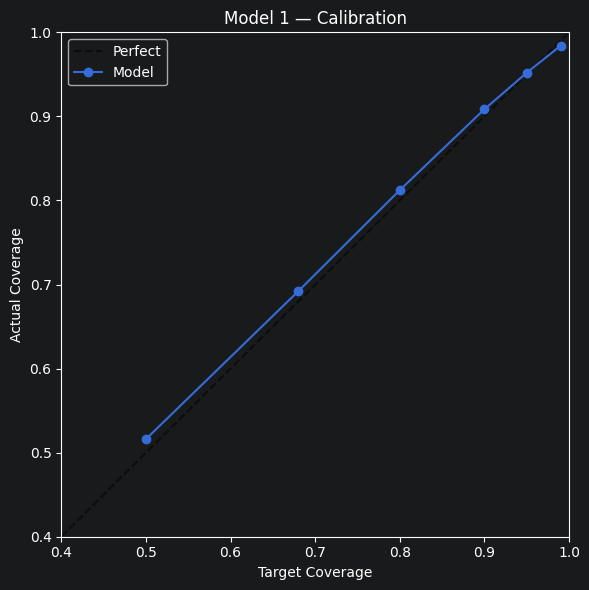

In [4]:
cal_df = evaluation.calibration_check(df['y_true'].values, df['mu'].values, df['sigma'].values)
display(cal_df.round(4))

fig = evaluation.plot_calibration(cal_df, title='Model 1 — Calibration')
plt.show()

## Residuals Histogram + Q-Q Plot

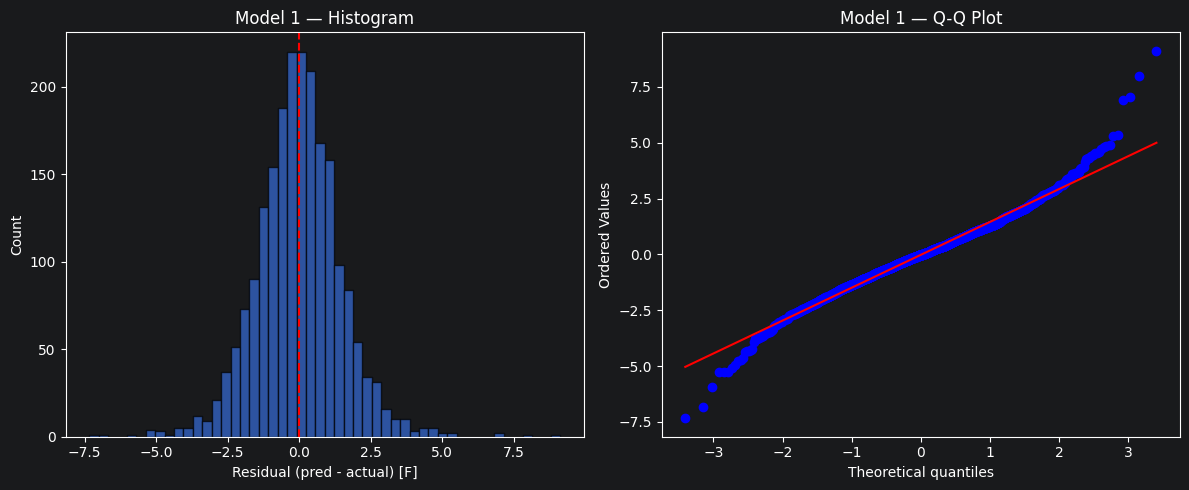

In [5]:
fig = evaluation.plot_residuals(df['y_true'].values, df['mu'].values, title='Model 1')
plt.show()

## Time Series — NY, Phoenix, Miami

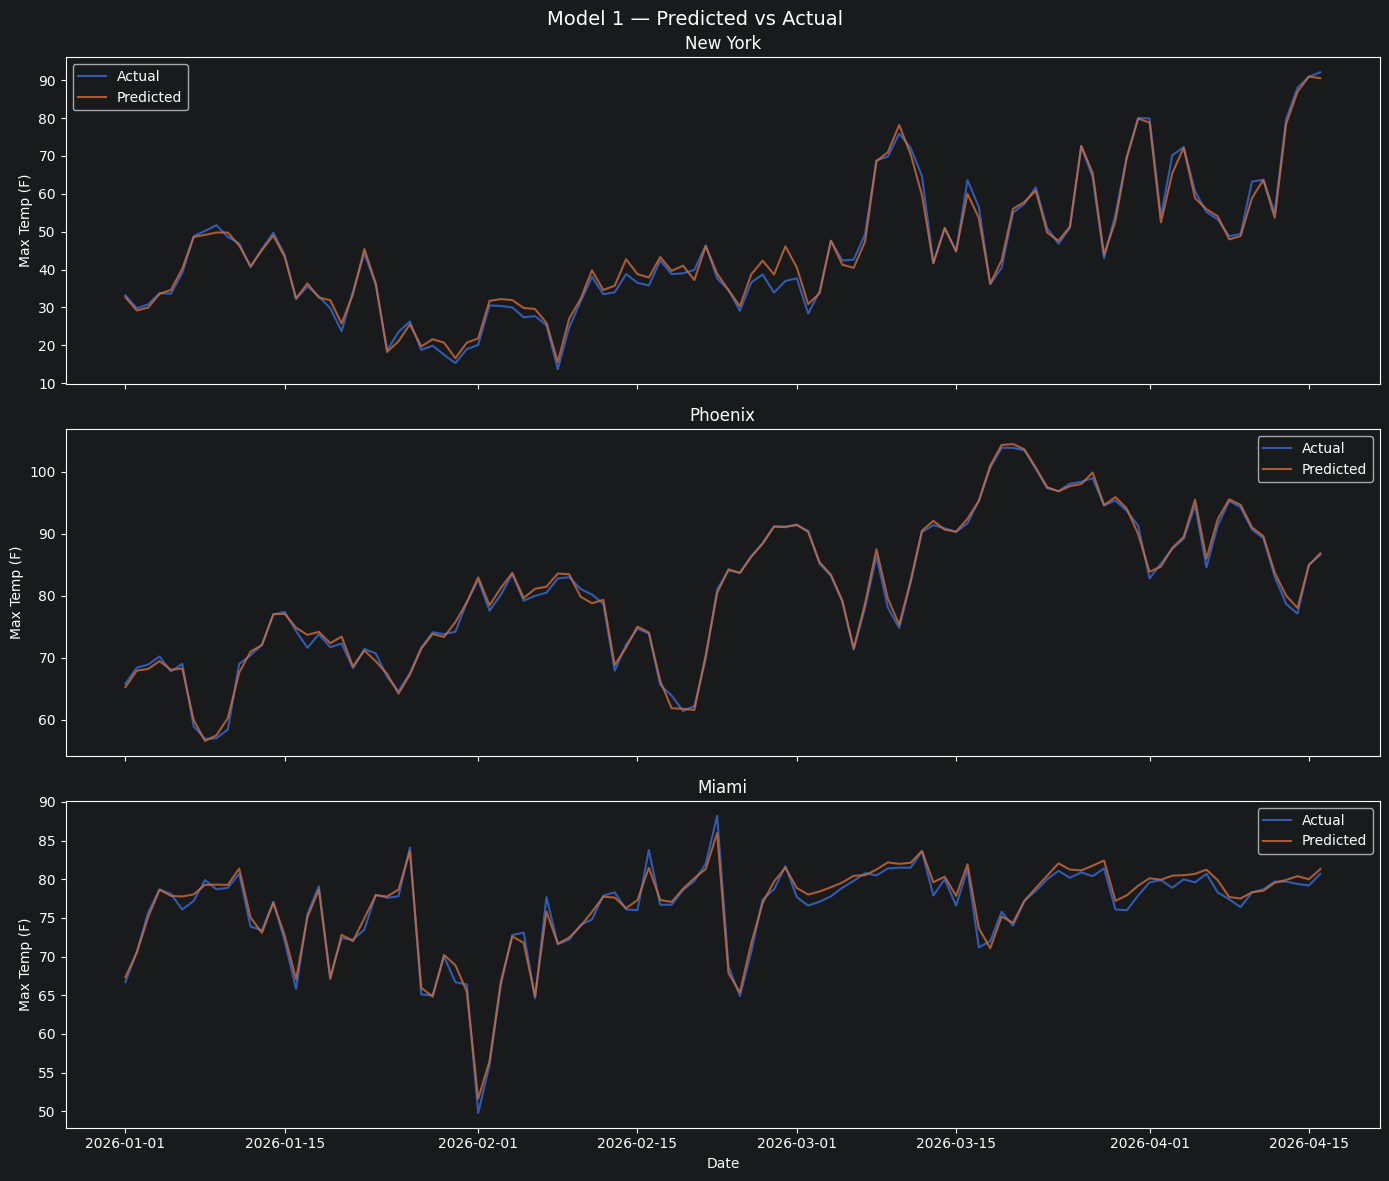

In [6]:
fig = evaluation.plot_timeseries(
    df, y_true_col='y_true', y_pred_col='mu',
    cities=['KXHIGHNY', 'KXHIGHTPHX', 'KXHIGHMIA'],
    title='Model 1 — Predicted vs Actual'
)
plt.show()

## MAE Heatmap by City and Month

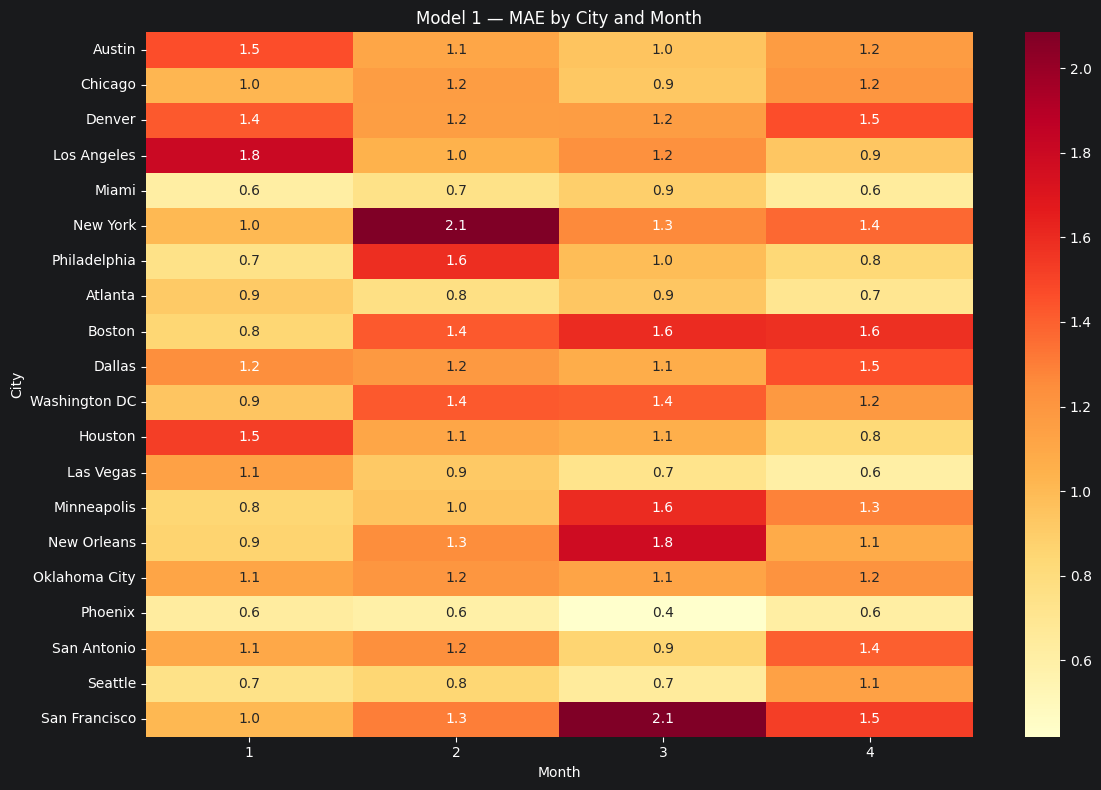

In [7]:
fig = evaluation.plot_mae_heatmap(
    df, y_true_col='y_true', y_pred_col='mu',
    title='Model 1 — MAE by City and Month'
)
plt.show()